<a href="https://colab.research.google.com/github/eugeniatate-duke/XAI-assumption-junction/blob/main/assumption_junction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

A telecommunications company is interested in understanding the factors that contribute to customer churn (customers leaving the company for a competitor) and developing interpretable models to predict which customers are at risk of churning.

The purpose of this notebook is to help the company analyze the data.

**Importing Libraries and Loading Dataset**

https://www.kaggle.com/datasets/blastchar/telco-customer-churn/data

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tools.tools import add_constant
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy.stats import shapiro

url = "https://raw.githubusercontent.com/eugeniatate-duke/XAI-assumption-junction/main/WA_Fn-UseC_-Telco-Customer-Churn.csv"

df = pd.read_csv(url)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Exploratory Data Analysis
Purpose: check whether assumptions about linear, logistic, and GAM models are met and identify factors associated with churn.


In [35]:
print("Shape:", df.shape)
display(df.info())
display(df.describe(include="all").T)

Shape: (7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 n

None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,3186-AJIEK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Data Manipulation**

I noticed TotalCharges is not numeric and should be converted to numeric. Churn also should be 0 for No and 1 for Yes.


In [36]:
# Convert TotalCharges to numeric.
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Convert the target to binary.
df["ChurnBinary"] = df["Churn"].map({"No": 0, "Yes": 1})

print("Missing values:")
print(df.isna().sum().sort_values(ascending=False).head())

TotalCharges     11
customerID        0
SeniorCitizen     0
Partner           0
Dependents        0
dtype: int64


In [37]:
df[np.isnan(df['TotalCharges'])]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,ChurnBinary
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No,0
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No,0
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No,0
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No,0
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No,0
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No,0
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No,0
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No,0
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No,0
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No,0


Since 11 customers are likely very new and have not incurred charges yet, we want to fill the values with zero.

In [38]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

print(df.isna().sum().sum(), "missing values remain")

0 missing values remain


In [39]:
# remove customerID column as it is not adding any value
df = df.drop("customerID", axis=1)

## Feature Grouping

In [43]:
feature_groups = {
    "Demographic": [
        "gender",
        "SeniorCitizen",
        "Partner",
        "Dependents"
    ],

    "Service": [
        "PhoneService",
        "MultipleLines",
        "InternetService",
        "OnlineSecurity",
        "OnlineBackup",
        "DeviceProtection",
        "TechSupport",
        "StreamingTV",
        "StreamingMovies"
    ],

    "Account": [
        "tenure",
        "Contract",
        "PaperlessBilling",
        "PaymentMethod"
    ],

    "Billing": [
        "MonthlyCharges",
        "TotalCharges"
    ]
}

numeric_features = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

categorical_features = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

# Churn Distribution

In [49]:
churn_counts = df["Churn"].value_counts()
print(churn_counts)
print("\nProportions:")
print(df["Churn"].value_counts(normalize=True).round(3))

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Proportions:
Churn
No     0.735
Yes    0.265
Name: proportion, dtype: float64


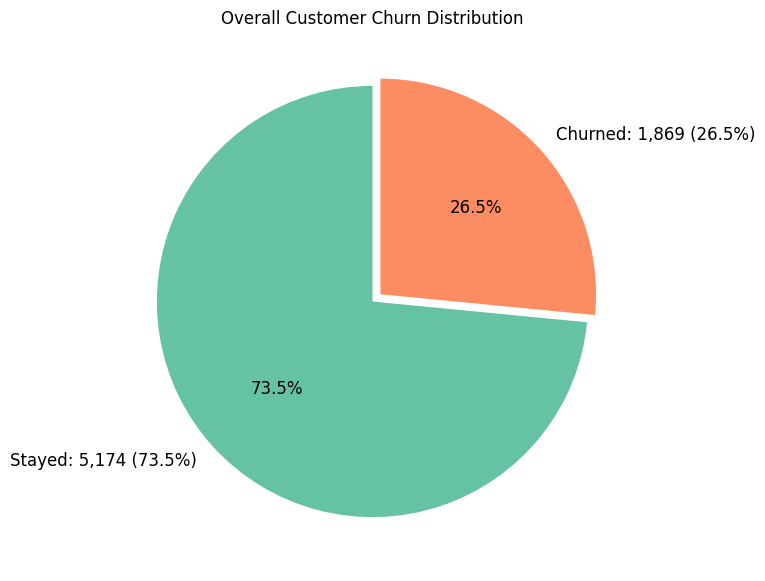

In [50]:
labels = [
    f"Stayed: {churn_counts['No']:,} ({churn_counts['No'] / len(df):.1%})",
    f"Churned: {churn_counts['Yes']:,} ({churn_counts['Yes'] / len(df):.1%})"
]

plt.figure(figsize=(7, 7))

plt.pie(
    churn_counts[["No", "Yes"]],
    labels=labels,
    colors=["#66c2a5", "#fc8d62"],
    autopct="%1.1f%%",
    startangle=90,
    explode=(0, 0.05),
    textprops={"fontsize": 12}
)

plt.title("Overall Customer Churn Distribution")
plt.show()

73.5% of customers stayed with the company, while 26.5% churned.
The target is imbalanced, and accuracy by itself is not to be used
to evaluate the models.

**Numeric Distributions**

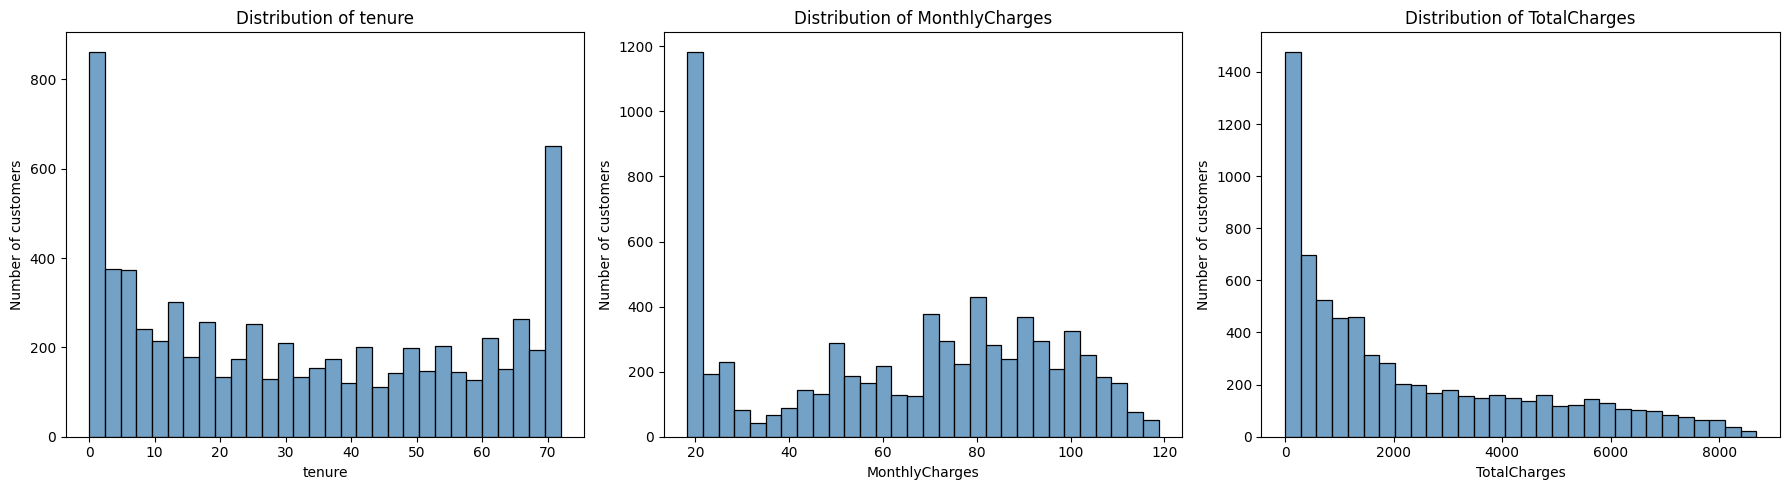

In [51]:
numeric_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, feature in zip(axes, numeric_features):
    sns.histplot(
        data=df,
        x=feature,
        bins=30,
        color="steelblue",
        ax=ax
    )

    ax.set_title(f"Distribution of {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Number of customers")

plt.tight_layout()
plt.show()

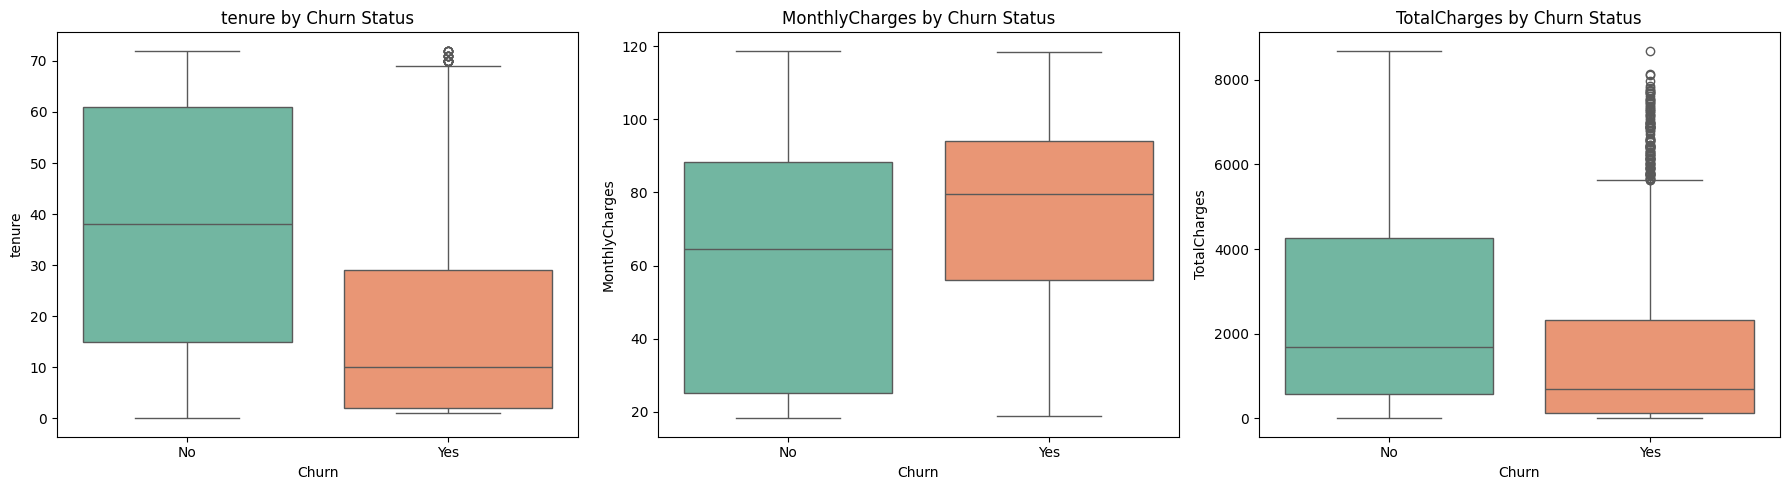

In [52]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, feature in zip(axes, numeric_features):
    sns.boxplot(
        data=df,
        x="Churn",
        y=feature,
        hue="Churn",
        palette={
            "No": "#66c2a5",
            "Yes": "#fc8d62"
        },
        legend=False,
        ax=ax
    )

    ax.set_title(f"{feature} by Churn Status")
    ax.set_xlabel("Churn")
    ax.set_ylabel(feature)

plt.tight_layout()
plt.show()


*   Customers with less tenure (< 30) tend to churn more
*   Customers with higher monthly (> 60) charges tend to churn more
*   Customers that churned contribute less to total charges





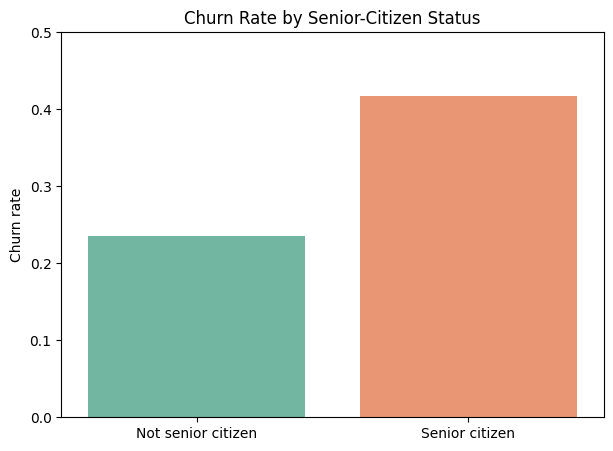

In [53]:
senior_churn = (
    df.groupby("SeniorCitizen")["ChurnBinary"]
    .mean()
    .reset_index()
)

senior_churn["SeniorCitizen"] = senior_churn["SeniorCitizen"].map({
    0: "Not senior citizen",
    1: "Senior citizen"
})

plt.figure(figsize=(7, 5))

sns.barplot(
    data=senior_churn,
    x="SeniorCitizen",
    y="ChurnBinary",
    hue="SeniorCitizen",
    palette=["#66c2a5", "#fc8d62"],
    legend=False
)

plt.title("Churn Rate by Senior-Citizen Status")
plt.xlabel("")
plt.ylabel("Churn rate")
plt.ylim(0, 0.5)

plt.show()

Senior Citizens tend to churn more than Non-senior citizens.

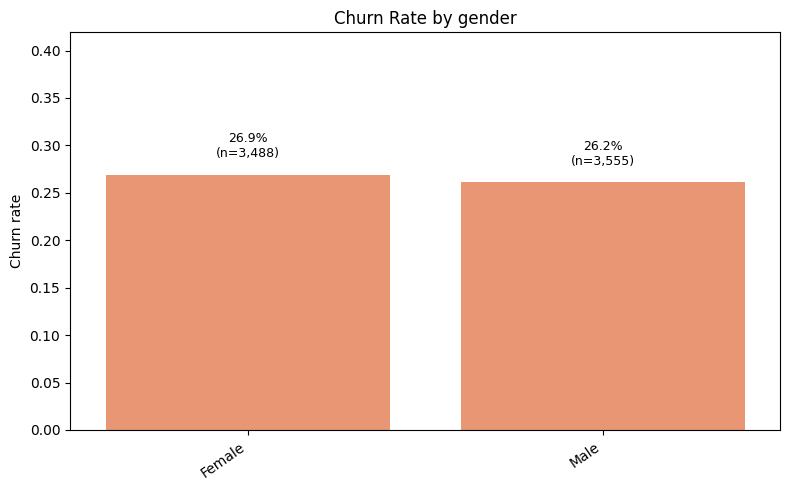

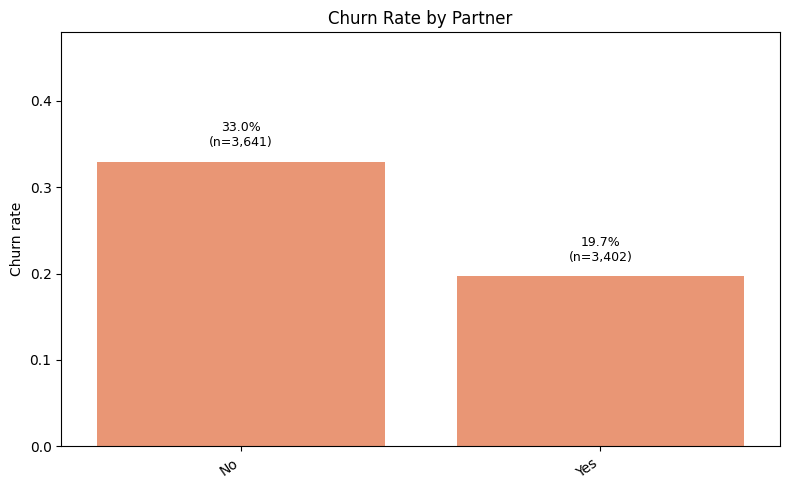

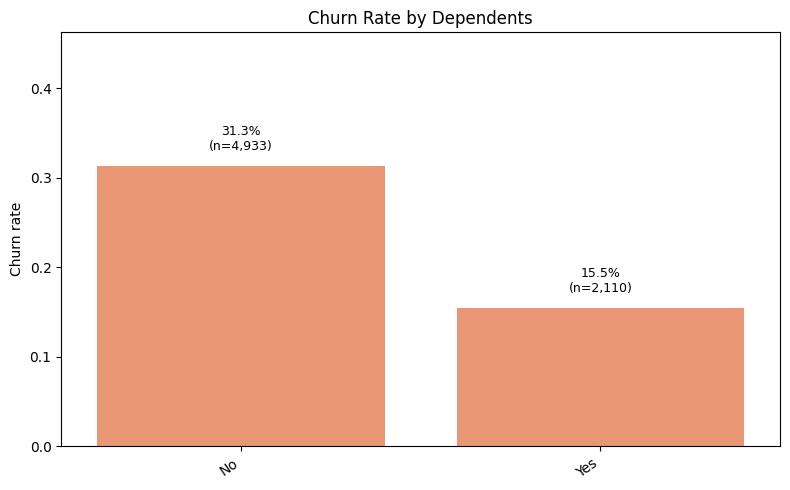

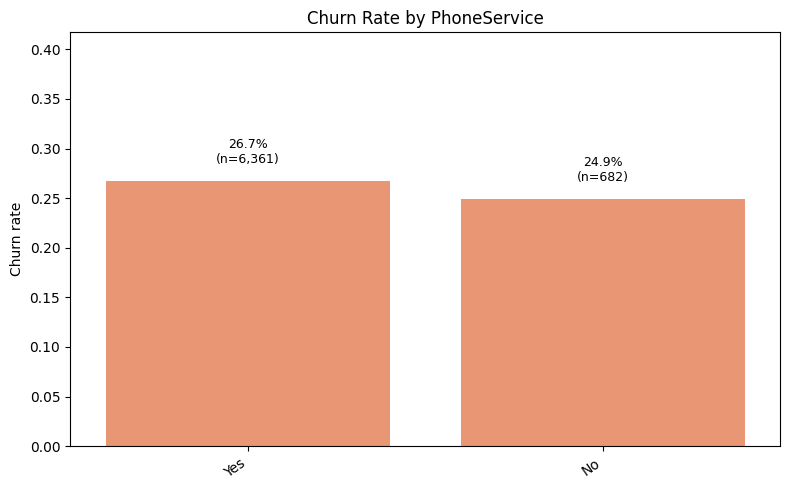

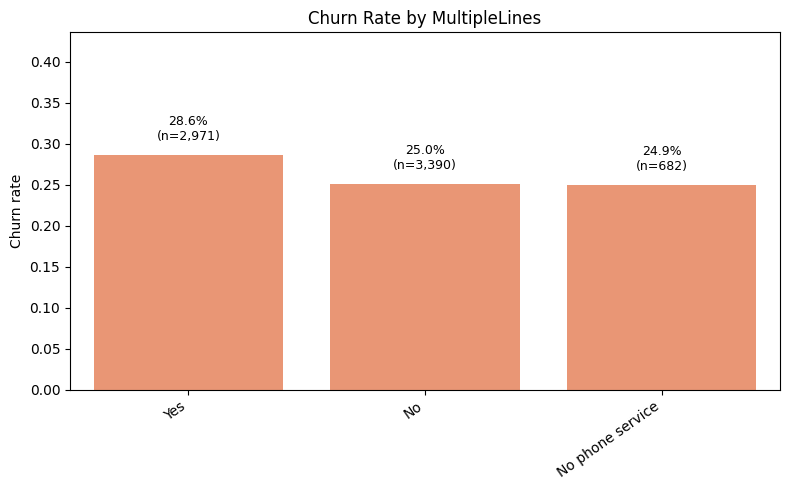

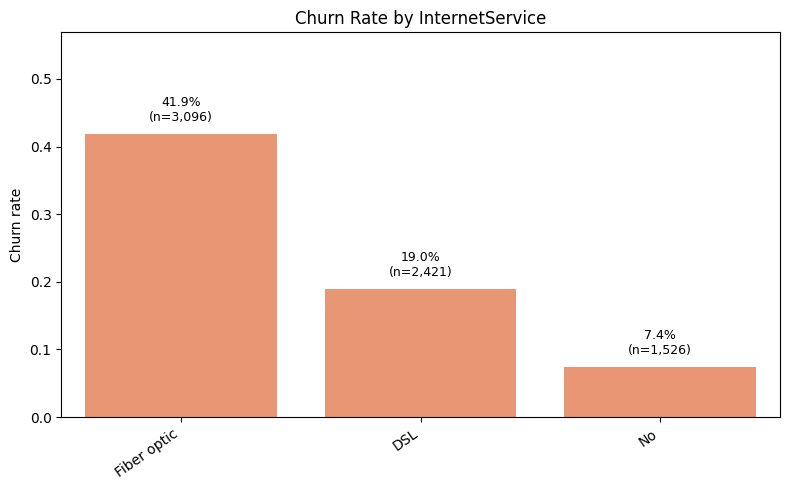

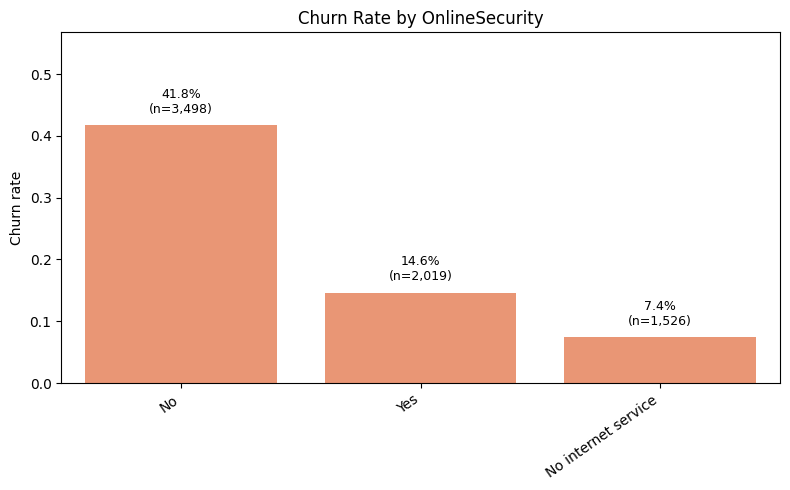

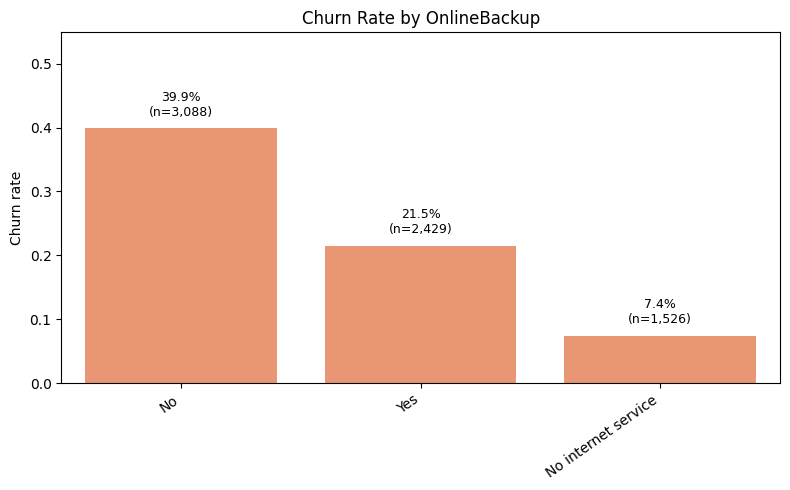

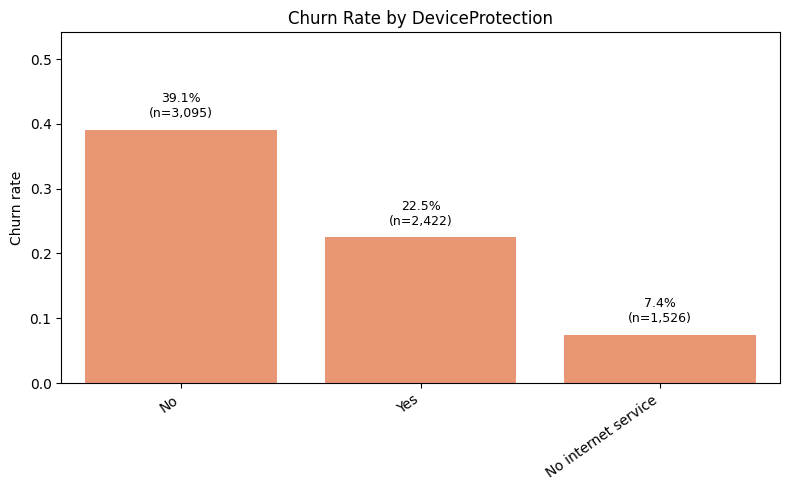

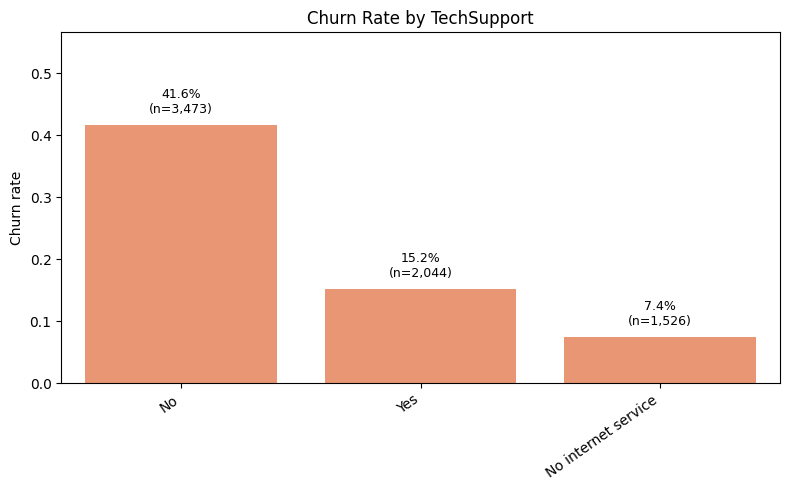

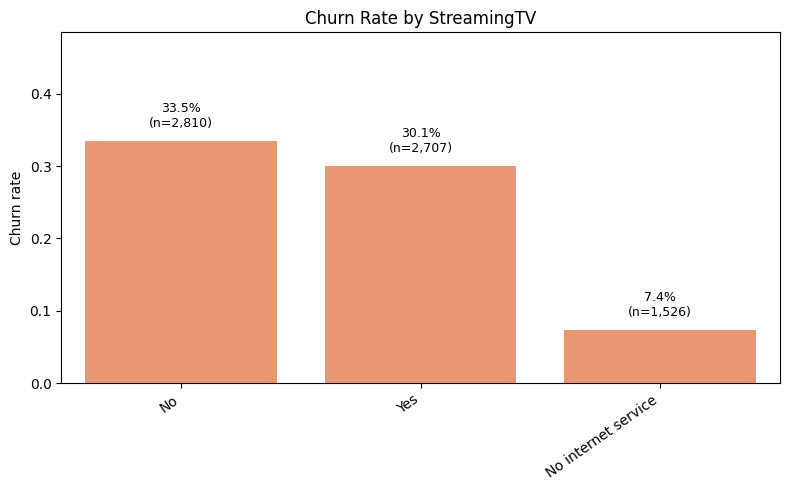

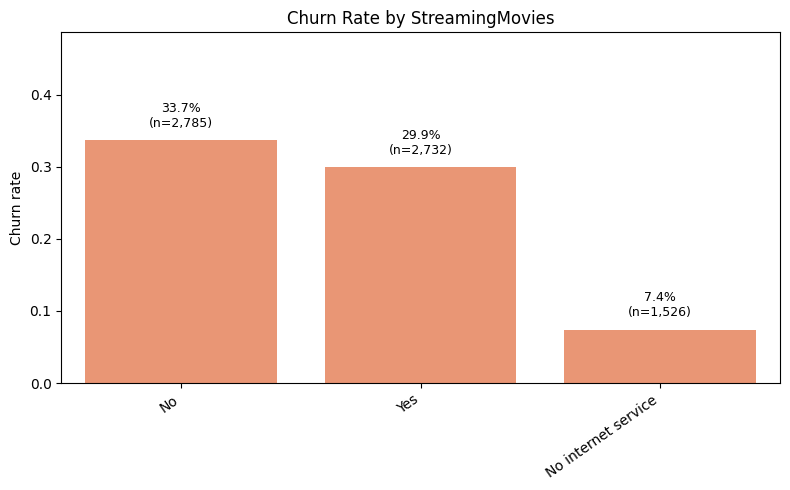

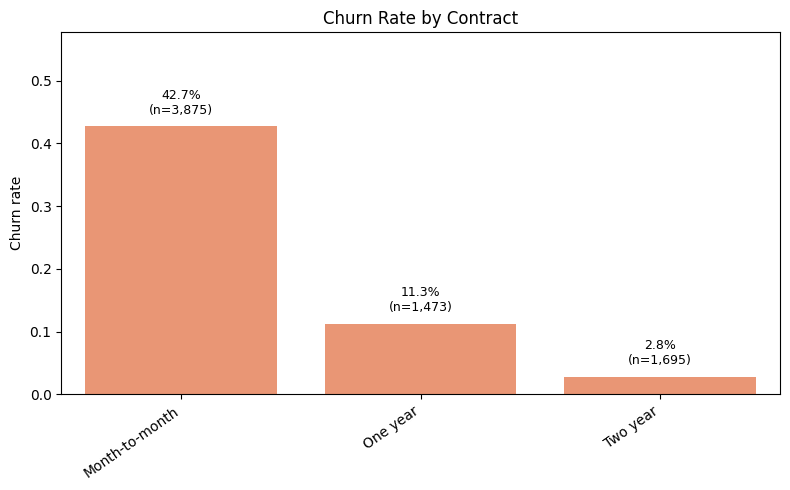

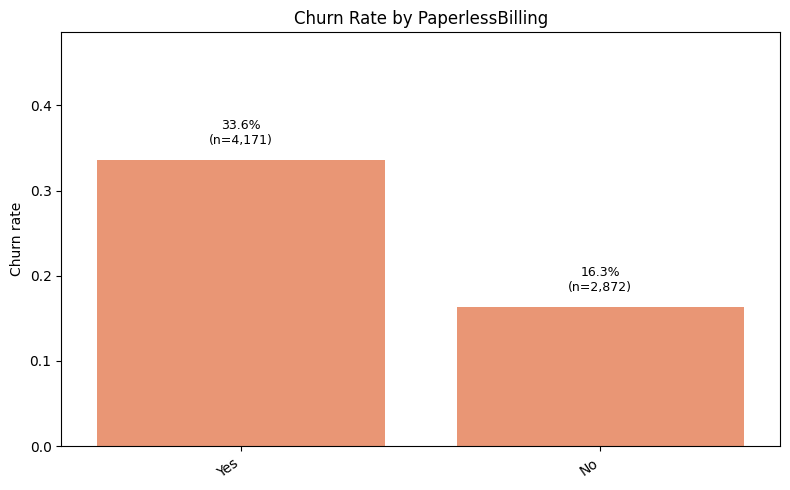

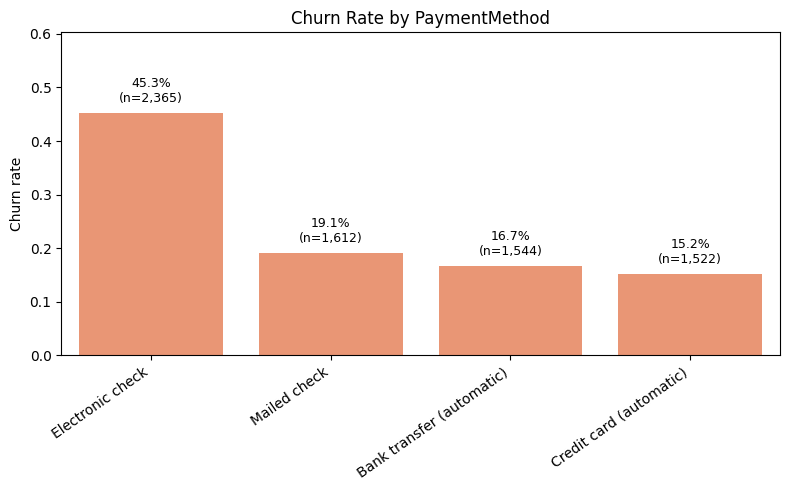

In [54]:
for feature in categorical_features:

    summary = (
        df.groupby(feature, observed=True)
        .agg(
            ChurnRate=("ChurnBinary", "mean"),
            Customers=("ChurnBinary", "size")
        )
        .sort_values("ChurnRate", ascending=False)
        .reset_index()
    )

    plt.figure(figsize=(8, 5))

    ax = sns.barplot(
        data=summary,
        x=feature,
        y="ChurnRate",
        color="#fc8d62"
    )

    for i, row in summary.iterrows():
        ax.text(
            i,
            row["ChurnRate"] + 0.015,
            f"{row['ChurnRate']:.1%}\n(n={row['Customers']:,})",
            ha="center",
            va="bottom",
            fontsize=9
        )

    plt.title(f"Churn Rate by {feature}")
    plt.xlabel("")
    plt.ylabel("Churn rate")
    plt.ylim(0, min(1, summary["ChurnRate"].max() + 0.15))
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    plt.show()

 - Single users with no dependents tend to churn more than partnered and/or with dependents
 - Number of phone lines, gender, phone service seem to not play a role in churn rates
 - Customers with no online security, no device protection, no online backup and no TechSupport tend to churn more
 - Customers with FiberOptic internet tend to churn more
 - Having Streaming Services does not appear to affect churning rates
 - Month-to-month contract appears to make customers churn more
 - Customer with paperless billing churn at double the rate
 - Customers that pay for services using e-check tend to churn at 2-3 x higher rate than customers paying using other methods

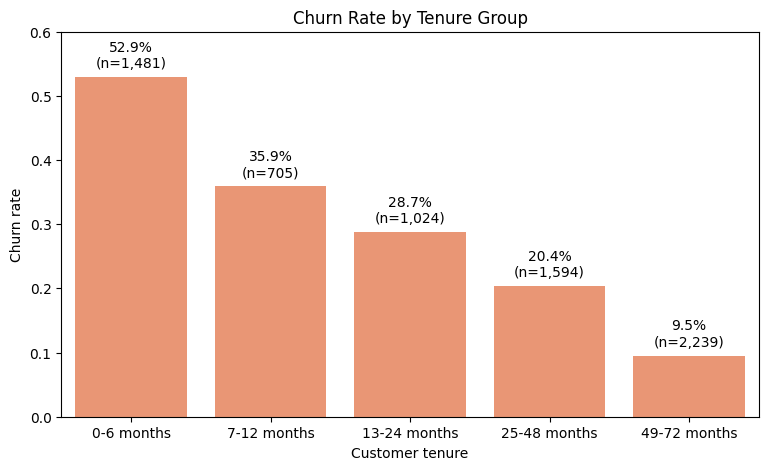

In [55]:
df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[-1, 6, 12, 24, 48, 72],
    labels=[
        "0-6 months",
        "7-12 months",
        "13-24 months",
        "25-48 months",
        "49-72 months"
    ]
)

tenure_summary = (
    df.groupby("TenureGroup", observed=True)
    .agg(
        ChurnRate=("ChurnBinary", "mean"),
        Customers=("ChurnBinary", "size")
    )
    .reset_index()
)

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=tenure_summary,
    x="TenureGroup",
    y="ChurnRate",
    color="#fc8d62"
)

for i, row in tenure_summary.iterrows():
    ax.text(
        i,
        row["ChurnRate"] + 0.015,
        f"{row['ChurnRate']:.1%}\n(n={row['Customers']:,})",
        ha="center",
        fontsize=10
    )

plt.title("Churn Rate by Tenure Group")
plt.xlabel("Customer tenure")
plt.ylabel("Churn rate")
plt.ylim(0, 0.6)
plt.show()

Customers that are new are much more likely to churn within the first 6 months, and customers are decreasingly likely to switch as their tenure grows with only 9.5% of customers churning if they have been with the company for over 4 years.

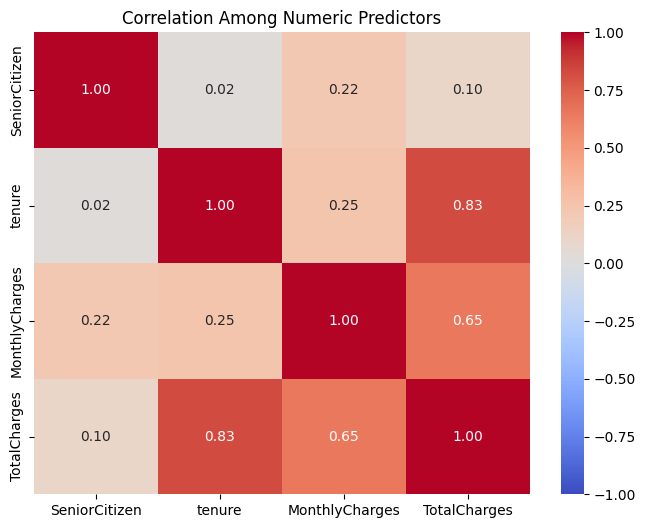

In [59]:
correlation_features = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

plt.figure(figsize=(8, 6))

sns.heatmap(
    df[correlation_features].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1
)

plt.title("Correlation Among Numeric Predictors")
plt.show()

The strongest correlation is between tenure and TotalCharges. This is expected because
customers who stay longer generally accumulate more charges. The correlation means that
their individual regression coefficients may be difficult to interpret independently.
The heatmap assesses multicollinearity; it does not measure churn rates.

# Linear Regression

In [60]:
from statsmodels.tools.tools import add_constant
import statsmodels.api as sm

model_features = numeric_features + categorical_features

X_encoded = pd.get_dummies(
    df[model_features],
    drop_first=True,
    dtype=float
)

y = df["ChurnBinary"]

X_linear = add_constant(X_encoded)

linear_model = sm.OLS(
    y,
    X_linear
).fit()

print(linear_model.summary())

                            OLS Regression Results                            
Dep. Variable:            ChurnBinary   R-squared:                       0.283
Model:                            OLS   Adj. R-squared:                  0.281
Method:                 Least Squares   F-statistic:                     125.9
Date:                Sat, 05 Sep 2026   Prob (F-statistic):               0.00
Time:                        03:42:17   Log-Likelihood:                -3064.5
No. Observations:                7043   AIC:                             6175.
Df Residuals:                    7020   BIC:                             6333.
Df Model:                          22                                         
Covariance Type:            nonrobust                                         
                                            coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------